## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Dataset 1: California Housing Dataset

This dataset contains information about housing in California districts.
- **Target**: Median house value for California districts
- **Features**: 8 numeric features including median income, house age, average rooms, etc.

In [2]:
# Load California Housing dataset
california = fetch_california_housing()
california_df = pd.DataFrame(california.data, columns=california.feature_names)
california_df['Target'] = california.target

print("California Housing Dataset Shape:", california_df.shape)
print("\nFirst few rows:")
california_df.head()

California Housing Dataset Shape: (20640, 9)

First few rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset statistics
print("Dataset Statistics:")
california_df.describe()

Dataset Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


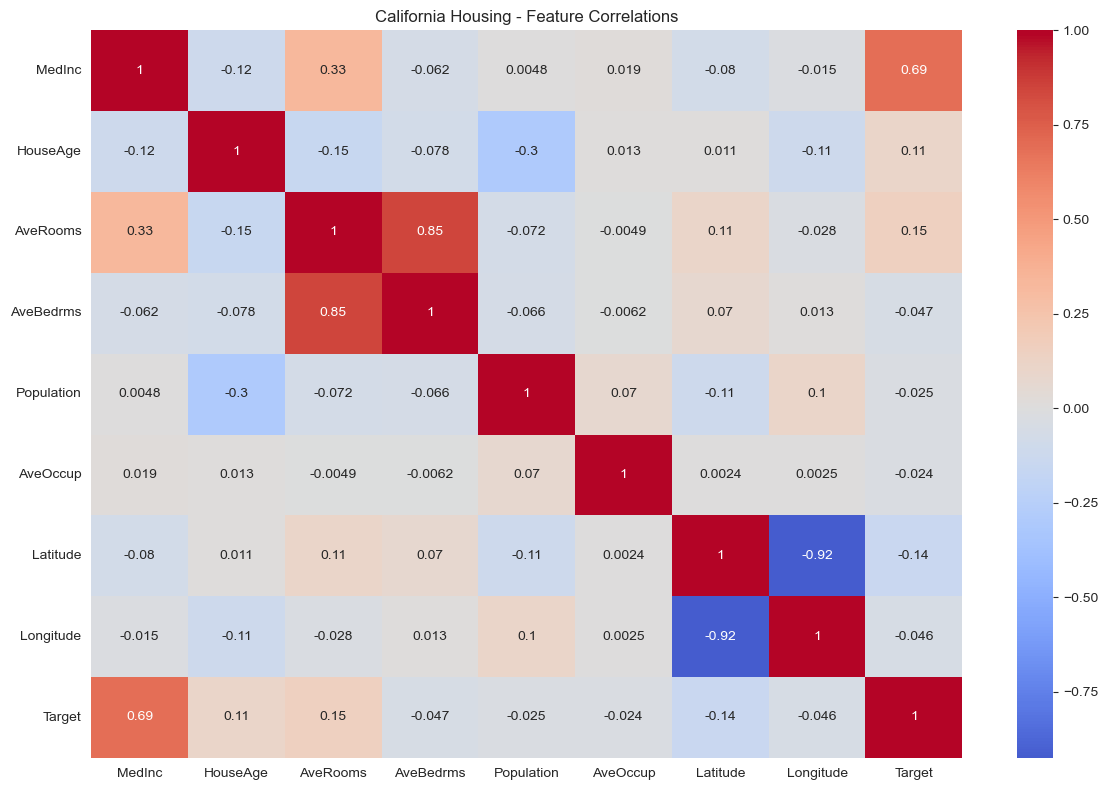

In [4]:
# Visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(california_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('California Housing - Feature Correlations')
plt.tight_layout()
plt.show()

### Simple Linear Regression - California Housing

Let's predict house prices using only the median income (the feature with highest correlation).

In [5]:
X_simple = california_df[['MedInc']].values

In [6]:
# Simple Linear Regression with one feature
X_simple = california_df[['MedInc']].values
y = california_df['Target'].values

# Split data
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train model
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

# Predictions
y_pred_simple = model_simple.predict(X_test_simple)

# Evaluate
print("Simple Linear Regression Results (California Housing):")
print(f"Coefficient: {model_simple.coef_[0]:.4f}")
print(f"Intercept: {model_simple.intercept_:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_simple):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_simple):.4f}")

Simple Linear Regression Results (California Housing):
Coefficient: 0.4193
Intercept: 0.4446
R² Score: 0.4589
RMSE: 0.8421
MAE: 0.6299


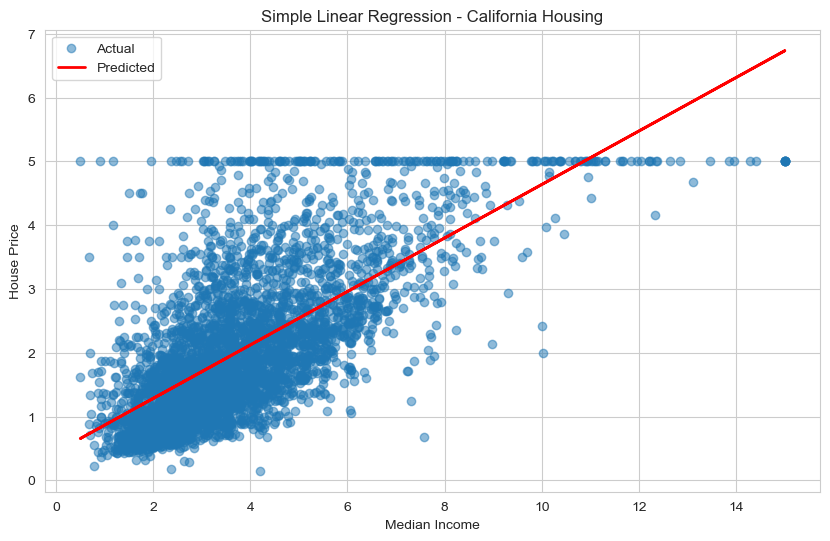

In [7]:
# Visualize Simple Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test, alpha=0.5, label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Predicted')
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.title('Simple Linear Regression - California Housing')
plt.legend()
plt.show()

### Multiple Linear Regression - California Housing

Now let's use all features to predict house prices.

In [8]:
# Multiple Linear Regression with all features
X = california_df.drop('Target', axis=1).values
y = california_df['Target'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

# Predictions
y_pred_multiple = model_multiple.predict(X_test)

# Evaluate
print("Multiple Linear Regression Results (California Housing):")
print(f"R² Score: {r2_score(y_test, y_pred_multiple):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_multiple)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_multiple):.4f}")

print("\nFeature Coefficients:")
for name, coef in zip(california.feature_names, model_multiple.coef_):
    print(f"{name}: {coef:.4f}")

Multiple Linear Regression Results (California Housing):
R² Score: 0.5758
RMSE: 0.7456
MAE: 0.5332

Feature Coefficients:
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337


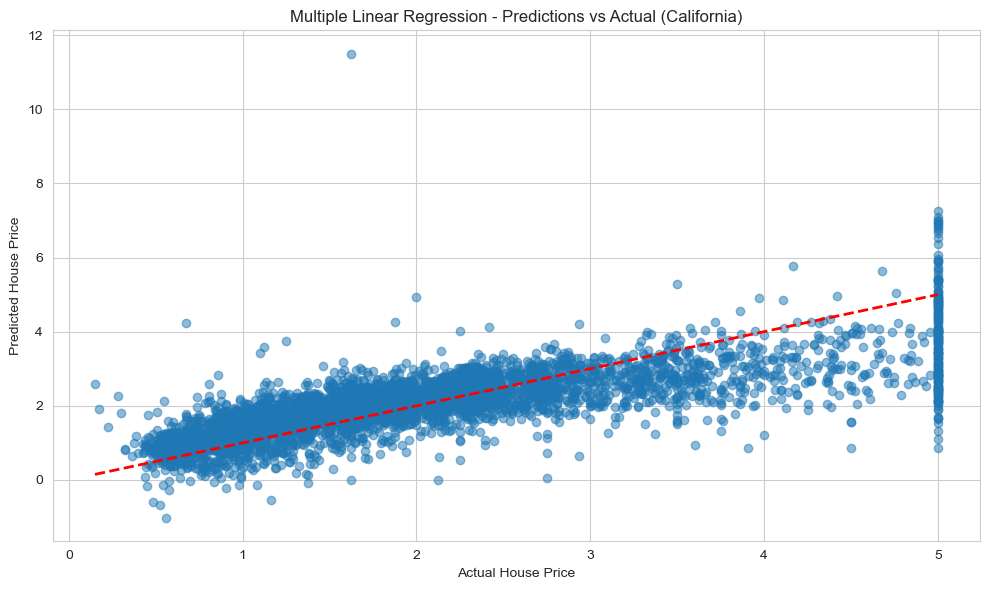

In [9]:
# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multiple, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Multiple Linear Regression - Predictions vs Actual (California)')
plt.tight_layout()
plt.show()

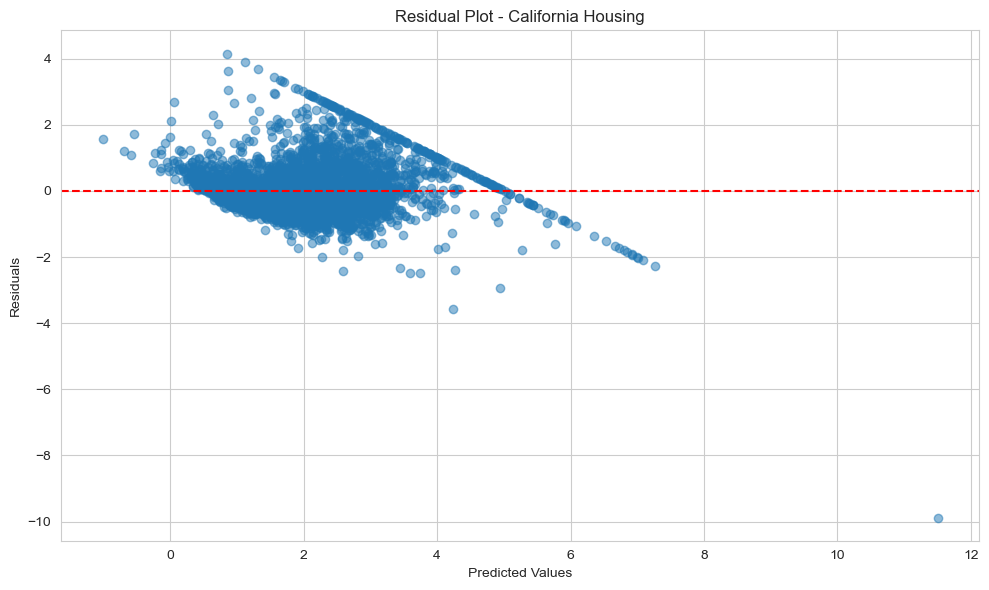

In [10]:
# Residual plot
residuals = y_test - y_pred_multiple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multiple, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - California Housing')
plt.tight_layout()
plt.show()

---
## Dataset 2: Diabetes Dataset

This dataset contains medical data for diabetes patients.
- **Target**: Quantitative measure of disease progression one year after baseline
- **Features**: 10 baseline variables (age, sex, BMI, blood pressure, etc.)

In [11]:
# Load Diabetes dataset
diabetes = load_diabetes()
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df['Target'] = diabetes.target

print("Diabetes Dataset Shape:", diabetes_df.shape)
print("\nFirst few rows:")
diabetes_df.head()

Diabetes Dataset Shape: (442, 11)

First few rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [12]:
# Dataset statistics
print("Dataset Statistics:")
diabetes_df.describe()

Dataset Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


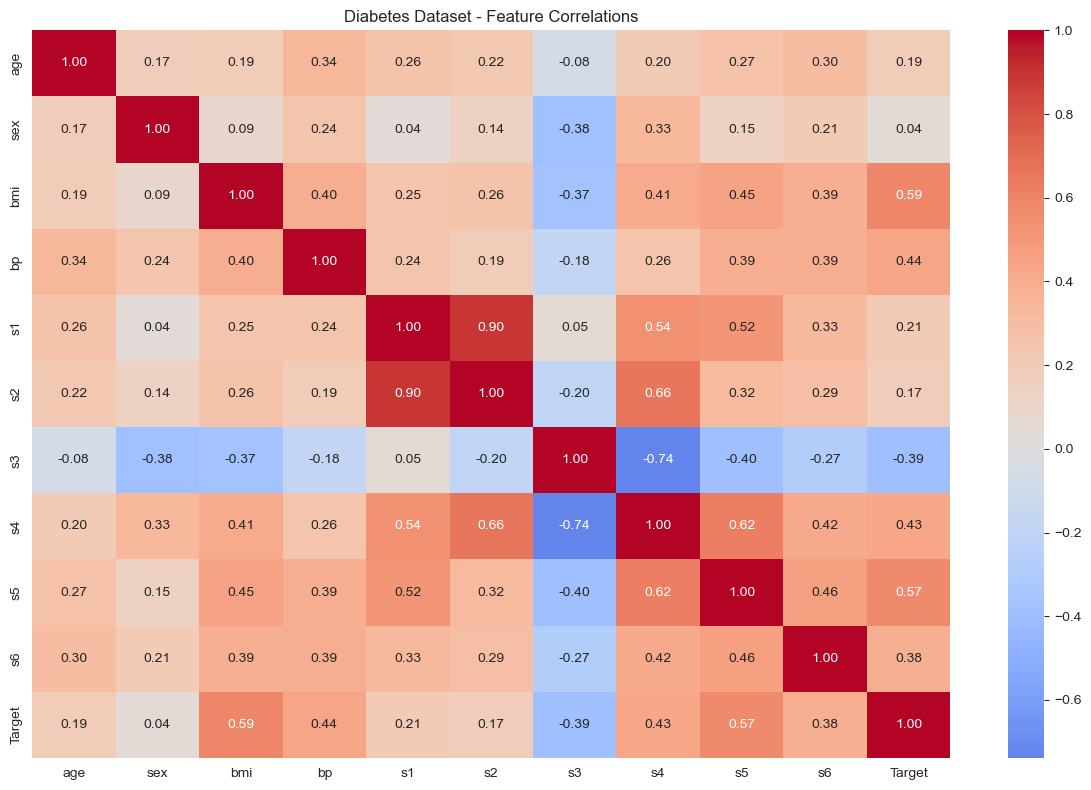

In [13]:
# Visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(diabetes_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Diabetes Dataset - Feature Correlations')
plt.tight_layout()
plt.show()

### Linear Regression - Diabetes Dataset

In [14]:
# Prepare data
X = diabetes_df.drop('Target', axis=1).values
y = diabetes_df['Target'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model_diabetes = LinearRegression()
model_diabetes.fit(X_train, y_train)

# Predictions
y_pred_diabetes = model_diabetes.predict(X_test)

# Evaluate
print("Linear Regression Results (Diabetes):")
print(f"R² Score: {r2_score(y_test, y_pred_diabetes):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_diabetes)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_diabetes):.4f}")

print("\nFeature Coefficients:")
for name, coef in zip(diabetes.feature_names, model_diabetes.coef_):
    print(f"{name}: {coef:.4f}")

Linear Regression Results (Diabetes):
R² Score: 0.4526
RMSE: 53.8534
MAE: 42.7941

Feature Coefficients:
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707


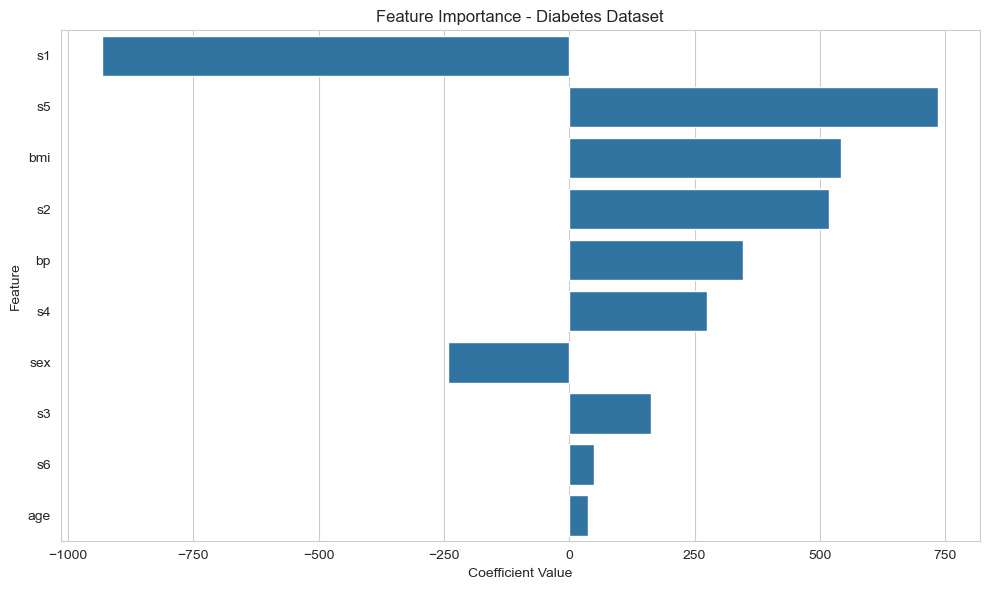

In [15]:
# Visualize feature importance
feature_importance = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': model_diabetes.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature')
plt.title('Feature Importance - Diabetes Dataset')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

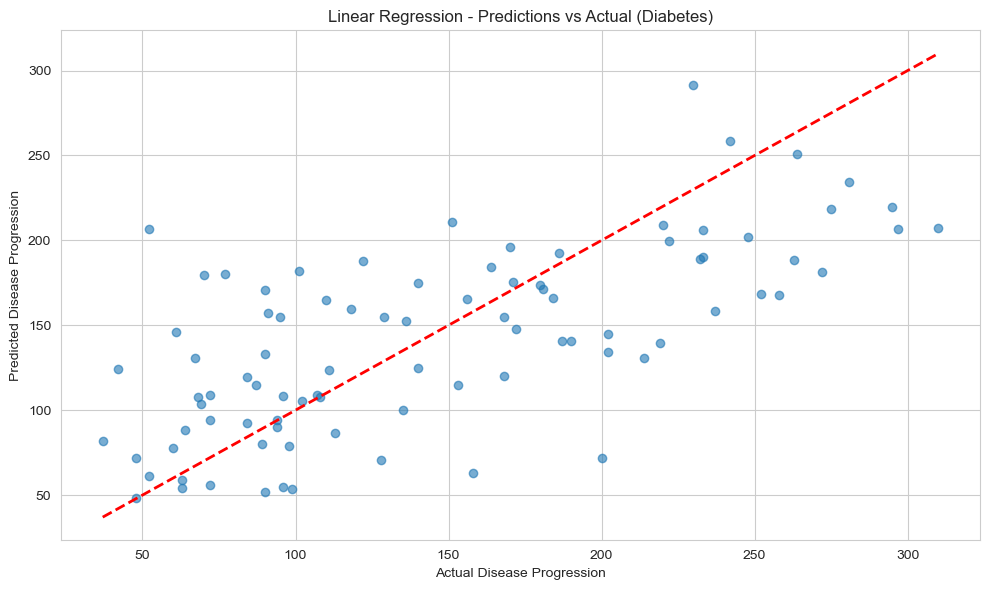

In [16]:
# Predictions vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_diabetes, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.title('Linear Regression - Predictions vs Actual (Diabetes)')
plt.tight_layout()
plt.show()

---
## Dataset 3: Custom Synthetic Dataset

Let's create a synthetic dataset with known relationships to demonstrate linear regression concepts.

In [17]:
from sklearn.datasets import make_regression

# Generate synthetic dataset
X_synthetic, y_synthetic = make_regression(
    n_samples=500,
    n_features=5,
    n_informative=3,
    noise=20,
    random_state=42
)

# Create DataFrame
synthetic_df = pd.DataFrame(
    X_synthetic,
    columns=[f'Feature_{i+1}' for i in range(X_synthetic.shape[1])]
)
synthetic_df['Target'] = y_synthetic

print("Synthetic Dataset Shape:", synthetic_df.shape)
print("\nFirst few rows:")
synthetic_df.head()

Synthetic Dataset Shape: (500, 6)

First few rows:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,-0.109610,0.546284,-0.088363,0.006422,-0.436386,71.915711
1,-1.024388,-0.926930,-0.252568,-0.059525,-3.241267,-115.327086
2,-2.650970,0.106430,1.091507,-0.254977,1.503993,30.002861
3,-0.850520,-0.138456,-0.580523,-1.224298,-0.209023,-135.823205
4,-0.322680,-0.756795,-0.250833,-1.421811,1.501334,-121.408351


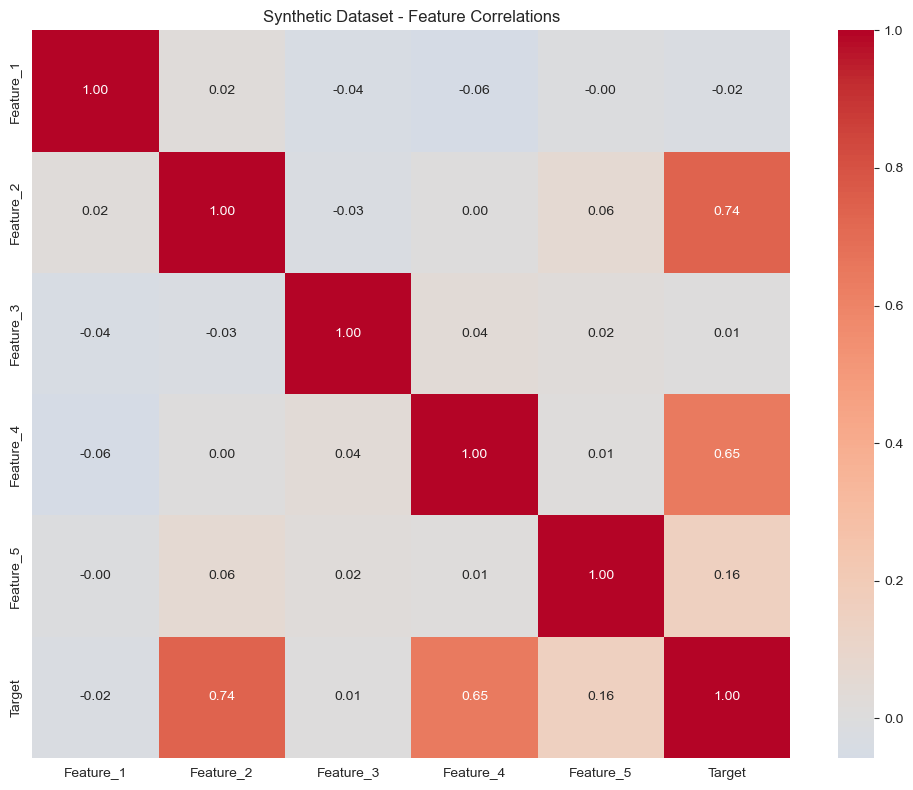

In [18]:
# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(synthetic_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Synthetic Dataset - Feature Correlations')
plt.tight_layout()
plt.show()